<a href="https://colab.research.google.com/github/HRashidLiaquat/PyTorch_Learning/blob/Linear_Regression_Project/Linear_Regression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Work Flow

**1.	Import important libraries**

**2.	Get data ready (turn into tensors)**

**3.	Build A linear Regression model**

**4.	Pick a loss function and optimizer**

**5.	Build a training loop**

**6.	Evaluate your model**

**7.	Test model with new data point**

**8.	Save model**



**Import important libraries**

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


**Gat data set ready (turn into tensors)**

In [ ]:
x_train = np.array([[3.3], [4.4],[5.5],[6.71],[6.93],[4.168],
                    [9.779],[6.182],[7.59],[2.167],[7.042],
                    [10.791],[5.313],[7.997],[3.1]], dtype=np.float32)
y_train = np.array([[1.7], [2.76], [2.09], [3.19], [1.694], [1.573],
                    [3.366], [2.596], [2.53], [1.221], [2.827],
                    [3.465],[1.65], [2.904], [1.3]], dtype=np.float32)
x_train,y_train

(array([[ 3.3  ],
        [ 4.4  ],
        [ 5.5  ],
        [ 6.71 ],
        [ 6.93 ],
        [ 4.168],
        [ 9.779],
        [ 6.182],
        [ 7.59 ],
        [ 2.167],
        [ 7.042],
        [10.791],
        [ 5.313],
        [ 7.997],
        [ 3.1  ]], dtype=float32),
 array([[1.7  ],
        [2.76 ],
        [2.09 ],
        [3.19 ],
        [1.694],
        [1.573],
        [3.366],
        [2.596],
        [2.53 ],
        [1.221],
        [2.827],
        [3.465],
        [1.65 ],
        [2.904],
        [1.3  ]], dtype=float32))

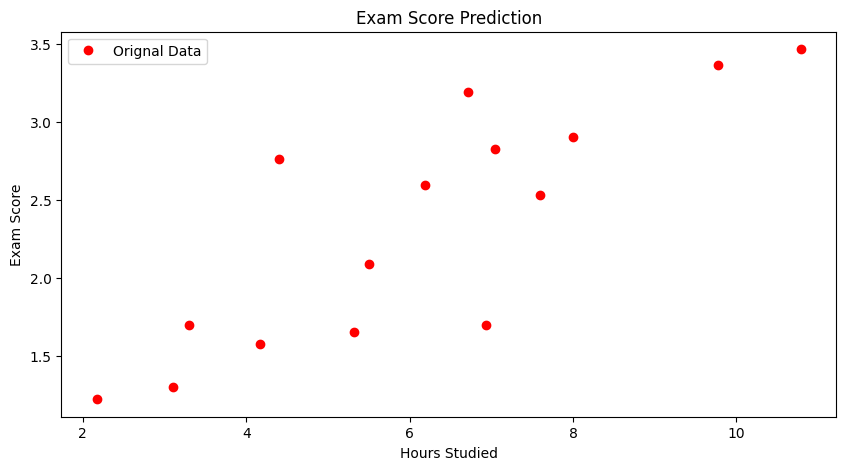

In [ ]:
fig=plt.figure(figsize=(10,5)) # Use create figure
plt.plot(x_train, y_train, 'ro', label = 'Orignal Data') # plot  the figure with respect to x_tarin and y_train 'ro' use for figure color lable use for lable into figure
plt.xlabel('Hours Studied') # create label for x exies
plt.ylabel('Exam Score') # create label for y exies
plt.legend() # Show label into figure
plt.title('Exam Score Prediction') # create figure title
plt.show() # show output


X_train we will train our model, we will test our model new data point, 8 hours ,

In [ ]:
x_train=torch.from_numpy(x_train) #convert into numpy to tensor
y_train=torch.from_numpy(y_train) # convert into numpy to tensor
x_train,y_train

(tensor([[ 3.3000],
         [ 4.4000],
         [ 5.5000],
         [ 6.7100],
         [ 6.9300],
         [ 4.1680],
         [ 9.7790],
         [ 6.1820],
         [ 7.5900],
         [ 2.1670],
         [ 7.0420],
         [10.7910],
         [ 5.3130],
         [ 7.9970],
         [ 3.1000]]),
 tensor([[1.7000],
         [2.7600],
         [2.0900],
         [3.1900],
         [1.6940],
         [1.5730],
         [3.3660],
         [2.5960],
         [2.5300],
         [1.2210],
         [2.8270],
         [3.4650],
         [1.6500],
         [2.9040],
         [1.3000]]))

slop = w*x + b now x is values given find the values of w and b then put the values in this formula(w*x + b) and find the slop.




**2. Build a Linear Regression model**

In [ ]:
class LinearRegression(nn.Module): # creating the mode call also inherited the nn modules class
  def __init__(self): # This is the child class contractor
    super().__init__() # this is the parent calss contractor
    self.linear = nn.Linear(1,1) # call the linear inherited the parent class means cnn modul class

  def forward(self, x): # also use method from parent class
    out=self.linear(x)
    return out          # return the values

In [ ]:
models = LinearRegression()

In [ ]:
models # call the object of this class

LinearRegression(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

**Start today work 01/07/2026**

In [ ]:
models.state_dict()

OrderedDict([('linear.weight', tensor([[-0.4308]])),
             ('linear.bias', tensor([-0.1724]))])

In [ ]:
list(models.parameters())

[Parameter containing:
 tensor([[-0.4308]], requires_grad=True),
 Parameter containing:
 tensor([-0.1724], requires_grad=True)]

**Pick a loss function and optimizer**
   1- MSE Loss funcation
   2- SGD Optimizer

   MSA = 1/N(YI - Y^)*2
   FOR Example = 1/15(acual_values - model_values)*2
   
   

In [ ]:
criterion = nn.MSELoss() # Pick the loss function.
optimizer = torch.optim.SGD(models.parameters(), lr = 1e-4) #0.0001 this is learning


In [ ]:
criterion,optimizer

(MSELoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.0001
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

**Build a training loop**

In [ ]:
num_epochs = 500

In [ ]:
for epoch in range(num_epochs): # this is the training loop
  models.train() # call the train method
  out=models(x_train) # forward pass
  loss=criterion(out,y_train)  # get loos my my model like loss = (actual values - model values)**2
  optimizer.zero_grad() # call the optimizer function for optimize the loos mean upddate w1 then apply again
  loss.backward() # backwaed propograction
  optimizer.step() # optimizer stet mean learning step
  if(epoch + 1) % 20 ==0: # if condication if modulas == 0 then true and print the values
    print(f'Epoch : [{epoch +1} / {num_epochs}], loss: { loss.item(): .6f}') # print the values if above condication true

Epoch : [20 / 500], loss:  20.871424
Epoch : [40 / 500], loss:  14.825046
Epoch : [60 / 500], loss:  10.551776
Epoch : [80 / 500], loss:  7.531640
Epoch : [100 / 500], loss:  5.397149
Epoch : [120 / 500], loss:  3.888583
Epoch : [140 / 500], loss:  2.822387
Epoch : [160 / 500], loss:  2.068832
Epoch : [180 / 500], loss:  1.536237
Epoch : [200 / 500], loss:  1.159803
Epoch : [220 / 500], loss:  0.893735
Epoch : [240 / 500], loss:  0.705668
Epoch : [260 / 500], loss:  0.572727
Epoch : [280 / 500], loss:  0.478747
Epoch : [300 / 500], loss:  0.412302
Epoch : [320 / 500], loss:  0.365317
Epoch : [340 / 500], loss:  0.332086
Epoch : [360 / 500], loss:  0.308575
Epoch : [380 / 500], loss:  0.291934
Epoch : [400 / 500], loss:  0.280147
Epoch : [420 / 500], loss:  0.271793
Epoch : [440 / 500], loss:  0.265863
Epoch : [460 / 500], loss:  0.261647
Epoch : [480 / 500], loss:  0.258643
Epoch : [500 / 500], loss:  0.256495


Evaluate the model

In [ ]:
models.eval() # Use evaluate function
with torch.no_grad(): # no need grad
  prediction=models(x_train) # Prediction input values
prediction.data.numpy() # convert data nupy values

array([[1.1520046 ],
       [1.5519186 ],
       [1.9518324 ],
       [2.3917377 ],
       [2.4717202 ],
       [1.4675732 ],
       [3.5074975 ],
       [2.199779  ],
       [2.7116687 ],
       [0.74009335],
       [2.5124388 ],
       [3.8754182 ],
       [1.8838471 ],
       [2.859637  ],
       [1.079293  ]], dtype=float32)

In [ ]:
y_train

tensor([[1.7000],
        [2.7600],
        [2.0900],
        [3.1900],
        [1.6940],
        [1.5730],
        [3.3660],
        [2.5960],
        [2.5300],
        [1.2210],
        [2.8270],
        [3.4650],
        [1.6500],
        [2.9040],
        [1.3000]])

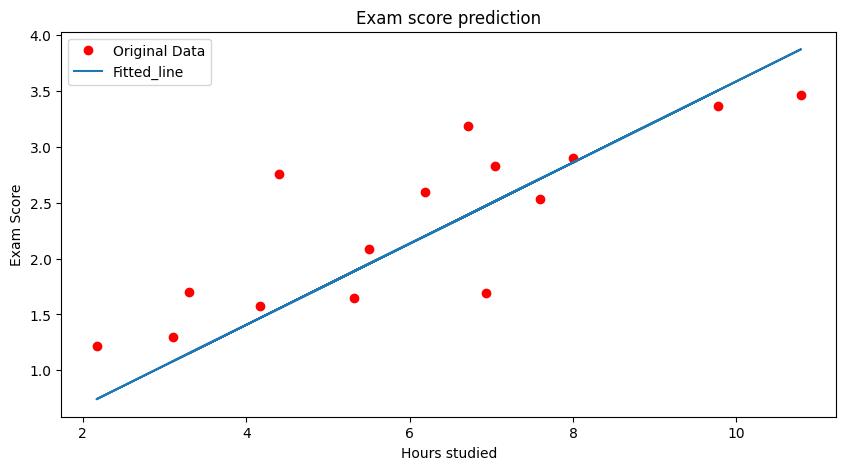

In [ ]:
fig = plt.figure(figsize=(10,5)) # create the figure
plt.plot(x_train.numpy(), y_train.numpy(), 'ro', label = 'Original Data') # x_train numpy arry and y_train numpy arry ro data point
plt.plot(x_train.numpy(),prediction,label = 'Fitted_line') # predication and fitted label
plt.xlabel('Hours studied') # hours label x exis
plt.ylabel('Exam Score') # Exam Score y y_exis
plt.legend() #
plt.title('Exam score prediction') # title the figure
plt.show() # Show result in figure

In [ ]:
models.state_dict() # show model output

OrderedDict([('linear.weight', tensor([[0.3636]])),
             ('linear.bias', tensor([-0.0477]))])

**Test model with new data point**

In [ ]:
new_hours_studied = 8.0 # new data point
new_hours_tensor = torch.tensor([[new_hours_studied]], dtype = torch.float32) #New data pint convert into tensor

In [ ]:
models.eval() # evulate funcatin
with torch.no_grad(): #no need any SGD
  new_exam_score = models(new_hours_tensor) #call new data point tensor
  print('predicted exam score for a student who strdied for 8 hours', new_exam_score.item()) # pint the result

predicted exam score for a student who strdied for 8 hours 2.860727548599243


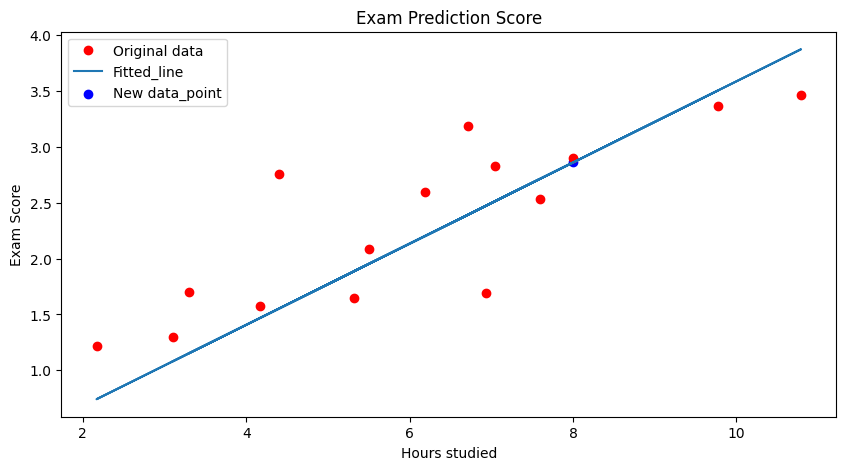

In [ ]:
fig= plt.figure(figsize=(10,5))
plt.plot(x_train.numpy(), y_train.numpy(), 'ro', label = 'Original data')
plt.plot(x_train.numpy(), prediction, label = 'Fitted_line')
plt.scatter([new_hours_studied], [new_exam_score.item()], color = 'blue', label = 'New data_point')
plt.xlabel('Hours studied')
plt.ylabel('Exam Score')
plt.legend()
plt.title('Exam Prediction Score')
plt.show()

**Save Model**

In [ ]:
models.state_dict() # Show model output

OrderedDict([('linear.weight', tensor([[0.3636]])),
             ('linear.bias', tensor([-0.0477]))])

In [ ]:
torch.save(models.state_dict(), '.LinearRegression.pth')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')